# Text Mining with CUAnalytics

This notebook demonstrates the new text mining workflow in `cuanalytics`.

We will:
- load a balanced sample from the Cornell movie review dataset
- convert the reviews into TF-IDF features with unigrams, bigrams, and trigrams
- inspect the learned terms
- find reviews similar to a query
- classify reviews as `positive` or `negative`
- cluster the transformed review vectors with K-means

In [1]:
import cuanalytics as ca

## 1) Load a balanced movie review sample

In [2]:
reviews = ca.load_movie_reviews_data()
reviews.head()


,label,text
0,positive,films adapted from comic books have had plenty...
1,positive,every now and then a movie comes along from a ...
2,positive,you've got mail works alot better than it dese...
3,positive,""" jaws "" is a rare film that grabs your attent..."
4,positive,moviemaking is a lot like being the general ma...


## 2) Split into training and test sets

In [3]:
train, test = ca.split_data(reviews, test_size=0.25, random_state=42)
len(train), len(test)

(1500, 500)

## 3) Fit a text vectorizer

We will use TF-IDF and keep unigrams, bigrams, and trigrams.

In [4]:
vec = ca.fit_text_vectorizer(
    train,
    text_col="text",
    target_col="label",
    method="tfidf",
    max_features=10000,
    max_n=2,
    stem=False,
)

vec.summary()


Text Vectorizer fitted successfully!
  Text column: text
  Method: tfidf
  Max n-gram size: 2
  Vocabulary size: 10000
  Stopwords removed: True
  Stemming enabled: False


## 4) Transform the reviews into a mining-ready feature table

In [5]:
train_vec = vec.transform(train)
test_vec = vec.transform(test)

train_vec.iloc[:5, :10]

,term__the,term__aaron,term__abandon,term__abandoned,term__aberdeen,term__abilities,term__ability,term__able,term__able_make,term__aboard
1738,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.039061,0.0,0.0
548,0.0,0.0,0.0,0.0,0.0,0.036921,0.0,0.000000,0.0,0.0
936,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1389,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
1607,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


## 5) Inspect important terms

In [6]:
vec.top_terms(top_n=15)

,term,score
0,film,7032
1,movie,4178
2,like,2724
3,just,2171
4,good,1781
5,time,1714
6,story,1608
7,character,1478
8,characters,1367
9,way,1278


In [7]:
#vec.top_terms_by_class(train, top_n=15)

## 6) Fit a topic model with LDA

Topic modeling works on term counts rather than TF-IDF weights, so we fit a separate topic model directly on the raw review text.


In [13]:
topic_lda = ca.fit_topic_lda(
    train,
    text_col="text",
    n_topics=15,
    max_features=5000,
    max_df=0.35,
    min_df=5,
    max_n=2,
    random_state=42,
)

topic_lda.summary()



Topic LDA fitted successfully!
  Topics: 15
  Vocabulary size: 5000
  Training documents: 1500
  Max iterations: 10
  Learning method: batch

Topic LDA fitted successfully!
  Topics: 15
  Vocabulary size: 5000
  Training documents: 1500
  Perplexity: 3448.1293
  Log likelihood: -2701801.6498
  Max document frequency: 0.35

Top terms by topic:
  Topic 0: comedy (0.8%), funny (0.4%), high (0.4%), school (0.4%), love (0.4%)
  Topic 1: batman (0.6%), joe (0.6%), action (0.5%), old (0.4%), robin (0.4%)
  Topic 2: funny (0.5%), evil (0.4%), world (0.4%), love (0.4%), thing (0.4%)
  Topic 3: alien (1.0%), bulworth (0.7%), jackal (0.6%), ripley (0.6%), gere (0.6%)
  Topic 4: smith (0.8%), love (0.5%), west (0.5%), harry (0.5%), wild (0.5%)
  Topic 5: effects (1.3%), special effects (0.8%), special (0.8%), world (0.8%), willis (0.6%)
  Topic 6: war (0.9%), ship (0.6%), troopers (0.5%), army (0.4%), world (0.4%)
  Topic 7: action (1.1%), jones (0.9%), great (0.6%), blade (0.5%), charles (0.4%)


In [17]:
topic_lda.describe_topics(top_n=8)


,topic,topic_name,top_terms,prevalence,dominant_documents
0,0,comedy / funny / high,"comedy (0.8%), funny (0.4%), high (0.4%), scho...",0.143806,240
1,1,batman / joe / action,"batman (0.6%), joe (0.6%), action (0.5%), old ...",0.066139,85
2,2,funny / evil / world,"funny (0.5%), evil (0.4%), world (0.4%), love ...",0.059396,80
3,3,alien / bulworth / jackal,"alien (1.0%), bulworth (0.7%), jackal (0.6%), ...",0.020041,25
4,4,smith / love / west,"smith (0.8%), love (0.5%), west (0.5%), harry ...",0.040657,64
5,5,effects / special effects / special,"effects (1.3%), special effects (0.8%), specia...",0.031131,41
6,6,war / ship / troopers,"war (0.9%), ship (0.6%), troopers (0.5%), army...",0.047757,64
7,7,action / jones / great,"action (1.1%), jones (0.9%), great (0.6%), bla...",0.028219,40
8,8,family / funny / truman,"family (0.4%), funny (0.4%), truman (0.4%), wo...",0.104667,172
9,9,jackie / love / chan,"jackie (0.7%), love (0.6%), chan (0.4%), ryan ...",0.074653,114


In [14]:
train_topics = topic_lda.transform(train)
test_topics = topic_lda.transform(test)

train_topics.head()


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14
1738,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.000360,0.994955
548,0.000222,0.057251,0.000222,0.000222,0.000222,0.000222,0.000222,0.000222,0.000222,0.000222,0.000222,0.939860,0.000222,0.000222,0.000222
936,0.000152,0.000152,0.000152,0.000152,0.249954,0.000152,0.000152,0.000152,0.414328,0.000152,0.082948,0.237054,0.014198,0.000152,0.000152
1389,0.000368,0.173935,0.000368,0.228837,0.379417,0.000368,0.000368,0.000368,0.000368,0.000368,0.000368,0.213759,0.000368,0.000368,0.000368
1607,0.000397,0.166334,0.000397,0.000397,0.000397,0.000397,0.000397,0.000397,0.000397,0.039433,0.000397,0.223457,0.063011,0.000397,0.503797


In [15]:
topic_lda.score()


{'log_likelihood': -2701801.6498107403,
 'perplexity': 3448.129298854277,
 'n_documents': 1500,
 'dominant_topic_counts': {0: 240,
  1: 85,
  2: 80,
  3: 25,
  4: 64,
  5: 41,
  6: 64,
  7: 40,
  8: 172,
  9: 114,
  10: 78,
  11: 274,
  12: 68,
  13: 35,
  14: 120}}

In [16]:
import pandas as pd
topic_lda.predict(pd.DataFrame({
    "text": [
        "A sharply acted sports drama with a lot of heart and energy.",
        "A visually polished kitchen story full of recipes, chefs, and meals.",
    ]
}))


,topic,topic_name
0,4,smith / love / west
1,10,black / death / world


## 7) Search for reviews similar to a query


In [8]:
result = vec.similarity_search(
    reviews,
    query="A witty, clever, and beautifully acted movie.",
    top_n=25,
)
import pandas as pd
pd.set_option("display.max_colwidth", 100)

display(result)

,label,text,similarity
1779,negative,"9 : its pathetic attempt at "" improving "" on a shakespeare classic . \n8 : its just another piec...",0.166283
562,positive,"aliens ! ! well , that is what this movie is about . \ncomputer generated aliens . \nok , the mo...",0.149582
233,positive,""" a bug's life "" may not be "" toy story , "" but it's more close than "" antz "" was . \ni really l...",0.127923
17,positive,"the ultimate match up between good and evil , "" the untouchables "" is an excellent movie because...",0.119863
249,positive,"upon arriving at the theater during the opening credits , i took my seat and prepared myself for...",0.117933
625,positive,"one of the best movies i've ever seen . \ni'd heard extremely good things about this movie , and...",0.108296
1745,negative,conventional wisdom among collectibles retailers is that children's items begin to dramatically ...,0.103689
1886,negative,i am continually amazed at movies like this . \nthat some producer would waste an abundance of t...,0.100590
1628,negative,writer/director lawrence kasdan had a hand in penning some of the biggest film successes of the ...,0.097060
443,positive,"'lake placid' is definately not your typical creature attacking people movie , ok so maybe it is...",0.092676


## 8) Fit a logistic regression classifier on the text features

In [ ]:
logit = ca.fit_logit(train_vec, formula="label ~ .")
logit.summary()


Logistic Regression fitted successfully!
  Classes: ['negative', 'positive']
  Features: 10000
  Training samples: 1500
  C parameter: 1.0
  Solver: lbfgs

LOGISTIC REGRESSION MODEL SUMMARY

MODEL INFORMATION:
----------------------------------------------------------------------
Target: label
Number of features: 10000
Classes: ['negative', 'positive']
Training samples: 1500
C parameter: 1.0
Solver: lbfgs

TRAINING FIT:
----------------------------------------------------------------------
Training Accuracy: 97.27%

Training Confusion Matrix:
               Actual positive  Actual negative
Pred positive              720               18
Pred negative               23              739

Per-Class Metrics:
          precision  recall  sensitivity  specificity     f1
negative     0.9698  0.9762       0.9762       0.9690 0.9730
positive     0.9756  0.9690       0.9690       0.9762 0.9723

Kappa: 0.9453

COEFFICIENTS:
----------------------------------------------------------------------
  


SCORE REPORT
Accuracy: 80.20%
Kappa: 0.6036

Confusion Matrix:
               Actual positive  Actual negative
Pred positive              208               50
Pred negative               49              193

Per-Class Metrics:
          precision  recall  sensitivity  specificity     f1
negative     0.7975  0.7942       0.7942       0.8093 0.7959
positive     0.8062  0.8093       0.8093       0.7942 0.8078


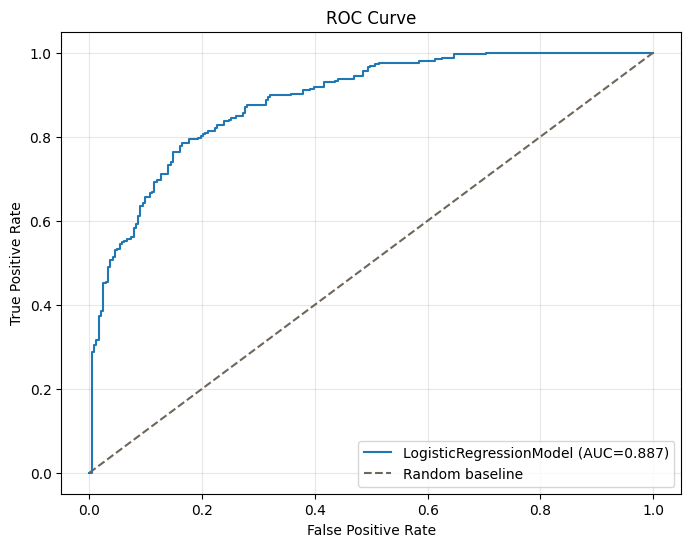

{'ax': <Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
 'data': {'LogisticRegressionModel': {'data':      threshold       fpr       tpr
   0          inf  0.000000  0.000000
   1     0.819798  0.004115  0.000000
   2     0.654987  0.004115  0.287938
   3     0.654294  0.008230  0.287938
   4     0.649077  0.008230  0.303502
   ..         ...       ...       ...
   135   0.353267  0.646091  0.988327
   136   0.352622  0.646091  0.996109
   137   0.337214  0.703704  0.996109
   138   0.336461  0.703704  1.000000
   139   0.139018  1.000000  1.000000
   
   [140 rows x 3 columns],
   'auc': 0.8869353573201391,
   'best_cutoff': 0.5176490287208824,
   'best_fpr': 0.1646090534979424,
   'best_tpr': 0.7859922178988327,
   'best_distance': 0.26999161337595134}}}

In [28]:
logit.score(test_vec)
ca.plot_roc(logit, test_vec, positive_class="positive")

## 9) Predict a brand-new review

In [27]:
new_review = vec.transform_query("A clever, funny, and beautifully acted movie.")
tough_review = vec.transform_query("""
    The film is so carefully made, so well acted, and so visually precise that I admired it almost constantly, 
    yet by the end I wasn't sure whether I'd seen something profound or just something expertly engineered to feel profound. 
    Several scenes are funny in a painful way, the performances are compelling without being exactly likable, and the story 
    keeps making bold choices that I respected more than enjoyed. I can easily imagine recommending it to someone and warning 
    them away from it in the same sentence.""")
tough_negative_review = vec.transform_query("""
    By the time the credits rolled, it felt less like I had watched a story unfold and more like I had sat through a long meeting 
    where everyone spoke with great confidence and nobody said anything worth carrying home. The cast moves through each scene 
    as if they've been given instructions rather than motivations, and every dramatic turn arrives with the calm inevitability of 
    paperwork being stamped. It is an impressively polished way to leave no trace at all.""")
negative_review = vec.transform_query("""
    This movie was terrible from start to finish. The acting felt stiff, the dialogue was painfully awkward, and the plot 
    wandered aimlessly without ever becoming interesting. Every scene seemed to drag on longer than it should, and by the end it 
    felt like a chore just to keep watching. It had a few ideas, but none of them were developed well enough to matter.
    """)
print(logit.predict(negative_review))

0    negative
Name: label, dtype: str


## 10) Cluster the transformed feature vectors

For clustering, we exclude the label column and use the text features only.

In [19]:
review_features = vec.transform(reviews, include_target=False)

kmeans = ca.fit_kmeans(review_features, formula=".", n_clusters=10, random_state=42)
kmeans.summary()


K-Means fitted successfully!
  Clusters: 10
  Features: 10000
  Samples: 2000

K-MEANS SUMMARY
Clusters: 10
Features: 10000
Samples: 2000
Inertia: 1872.3335
Silhouette: 0.0031

Cluster Counts:
{0: 16, 1: 122, 2: 756, 3: 137, 4: 249, 5: 305, 6: 65, 7: 310, 8: 12, 9: 28}



In [27]:
clustered_reviews = reviews.copy()
clustered_reviews["cluster"] = kmeans.labels_
clustered_reviews[["text", "label", "cluster"]].head(10)

,text,label,cluster
0,films adapted from comic books have had plenty...,positive,2
1,every now and then a movie comes along from a ...,positive,9
2,you've got mail works alot better than it dese...,positive,4
3,""" jaws "" is a rare film that grabs your attent...",positive,0
4,moviemaking is a lot like being the general ma...,positive,0
5,"on june 30 , 1960 , a self-taught , idealistic...",positive,7
6,"apparently , director tony kaye had a major ba...",positive,9
7,one of my colleagues was surprised when i told...,positive,6
8,"after bloody clashes and independence won , lu...",positive,6
9,the american action film has been slowly drown...,positive,5
